In [ ]:
!pip install kagglehub xgboost scikit-learn imbalanced-learn matplotlib seaborn --quiet

import kagglehub
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("All libraries loaded")


All libraries loaded


In [ ]:
path = kagglehub.dataset_download("humera11/cicbelldnsexf2021")
print("Dataset path:", path)

100%|██████████| 11.6M/11.6M [00:00<00:00, 187MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1


In [ ]:
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print("  ", f)

df_list = []
for f in csv_files:
    tmp = pd.read_csv(f, low_memory=False)
    df_list.append(tmp)

df = pd.concat(df_list, ignore_index=True)
print(f"\nMerged shape: {df.shape}")

Found 36 CSV file(s):
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_3.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_1.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_1.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateful_features-benign_heavy_2.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_3.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Benign/stateless_features-benign_heavy_2.pcap.csv
   /root/.cache/kagglehub/datasets/humera11/cicbelldnsexf2021/versions/1/Attack_heavy_Benign/Attacks/stateful_features-heav

In [ ]:
df.head(5)

,rr,A_frequency,NS_frequency,CNAME_frequency,SOA_frequency,NULL_frequency,PTR_frequency,HINFO_frequency,MX_frequency,TXT_frequency,...,numeric,entropy,special,labels,labels_max,labels_average,longest_word,sld,len,subdomain
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Column names")
print(df.columns.tolist())

print("\nData types")
print(df.dtypes)

print("\n Missing values")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nLabel distribution")
# The label column is typically 'label' or 'Label' or 'class'
# Auto-detect it
label_col = None
for col in df.columns:
    if col.strip().lower() in ['label', 'class', 'target', 'attack_type', 'type']:
        label_col = col
        break

if label_col is None:
    # Last column is often the label in CIC datasets
    label_col = df.columns[-1]

print(f"Detected label column: '{label_col}'")
print(df[label_col].value_counts())


Column names
['rr', 'A_frequency', 'NS_frequency', 'CNAME_frequency', 'SOA_frequency', 'NULL_frequency', 'PTR_frequency', 'HINFO_frequency', 'MX_frequency', 'TXT_frequency', 'AAAA_frequency', 'SRV_frequency', 'OPT_frequency', 'rr_type', 'rr_count', 'rr_name_entropy', 'rr_name_length', 'distinct_ns', 'distinct_ip', 'unique_country', 'unique_asn', 'distinct_domains', 'reverse_dns', 'a_records', 'unique_ttl', 'ttl_mean', 'ttl_variance', 'timestamp', 'FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric', 'entropy', 'special', 'labels', 'labels_max', 'labels_average', 'longest_word', 'sld', 'len', 'subdomain']

Data types
rr                  float64
A_frequency         float64
NS_frequency        float64
CNAME_frequency     float64
SOA_frequency       float64
NULL_frequency      float64
PTR_frequency       float64
HINFO_frequency     float64
MX_frequency        float64
TXT_frequency       float64
AAAA_frequency      float64
SRV_frequency       float64
OPT_frequency       float64
rr_

In [ ]:
print("\nMissing values before imputation:")
missing_counts = df.isnull().sum()
missing_counts_greater_than_zero = missing_counts[missing_counts > 0]
print(missing_counts_greater_than_zero)

# --- Imputation of missing values ---

total_rows = len(df)

# Identify columns where ALL values are missing
all_missing_cols = missing_counts[missing_counts == total_rows].index.tolist()

if all_missing_cols:
    print(f"\nDropping columns with all values missing: {all_missing_cols}")
    df = df.drop(columns=all_missing_cols)
else:
    print("\nNo columns with all values missing.")

# Identify remaining columns with missing values after dropping all-missing columns
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if not remaining_missing.empty:
    print(f"\nImputing remaining columns with missing values:\n{remaining_missing}")

    # Separate numerical and categorical columns for imputation
    numerical_cols_to_impute = df[remaining_missing.index].select_dtypes(include=np.number).columns.tolist()
    categorical_cols_to_impute = df[remaining_missing.index].select_dtypes(include='object').columns.tolist()

    # Impute numerical columns with median
    for col in numerical_cols_to_impute:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Imputed numerical column '{col}' with median: {median_val}")

    # Impute categorical columns with mode
    for col in categorical_cols_to_impute:
        # Mode might return multiple values, pick the first one
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  Imputed categorical column '{col}' with mode: {mode_val}")

    print("\nMissing values after imputation:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("\nNo remaining missing values to impute.")


Missing values before imputation:
rr                  757211
A_frequency         757211
NS_frequency        757211
CNAME_frequency     757211
SOA_frequency       757211
NULL_frequency      757211
PTR_frequency       757211
HINFO_frequency     757211
MX_frequency        757211
TXT_frequency       757211
AAAA_frequency      757211
SRV_frequency       757211
OPT_frequency       757211
rr_type             757211
rr_count            757211
rr_name_entropy     757211
rr_name_length      757211
distinct_ns         757211
distinct_ip         757211
unique_country      757211
unique_asn          757211
distinct_domains    757211
reverse_dns         757211
a_records           757211
unique_ttl          757211
ttl_mean            757211
ttl_variance        757211
timestamp           262105
FQDN_count          262105
subdomain_length    262105
upper               262105
lower               262105
numeric             262105
entropy             262105
special             262105
labels              

/tmp/ipykernel_15659/1358375205.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_15659/1358375205.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

  Imputed numerical column 'rr' with median: 0.0
  Imputed numerical column 'A_frequency' with median: 0.0
  Imputed numerical column 'NS_frequency' with median: 0.0
  Imputed numerical column 'CNAME_frequency' with median: 0.0
  Imputed numerical column 'SOA_frequency' with median: 0.0
  Imputed numerical column 'NULL_frequency' with median: 0.0
  Imputed numerical column 'PTR_frequency' with median: 0.0
  Imputed numerical column 'HINFO_frequency' with median: 0.0
  Imputed numerical column 'MX_frequency' with median: 0.0
  Imputed numerical column 'TXT_frequency' with median: 0.0
  Imputed numerical column 'AAAA_frequency' with median: 0.0
  Imputed numerical column 'SRV_frequency' with median: 0.0
  Imputed numerical column 'OPT_frequency' with median: 0.0
  Imputed numerical column 'rr_count' with median: 0.0
  Imputed numerical column 'rr_name_entropy' with median: 3.102730590380101
  Imputed numerical column 'rr_name_length' with median: 24.0
  Imputed numerical column 'distinct

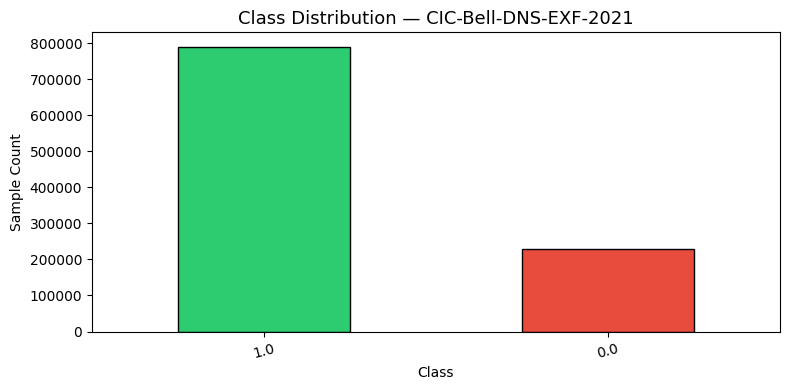

Plot saved


In [ ]:
plt.figure(figsize=(8, 4))
df[label_col].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c','#e67e22'],
                                  edgecolor='black')
plt.title("Class Distribution — CIC-Bell-DNS-EXF-2021", fontsize=13)
plt.xlabel("Class")
plt.ylabel("Sample Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Plot saved")

In [ ]:
X = df.drop(columns=[label_col])
y = df[label_col]

print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")

# Apply LabelEncoder to categorical columns in X
for column in X.columns:
    if X[column].dtype == 'object':
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])
        print(f"Encoded categorical column: {column}")

print("\nData types after encoding:")
print(X.dtypes.value_counts())
print("\nFirst 5 rows of X after encoding:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

Original X shape: (1019316, 41)
Original y shape: (1019316,)
Encoded categorical column: rr_type
Encoded categorical column: distinct_ip
Encoded categorical column: unique_country
Encoded categorical column: unique_asn
Encoded categorical column: distinct_domains
Encoded categorical column: reverse_dns
Encoded categorical column: unique_ttl
Encoded categorical column: timestamp
Encoded categorical column: longest_word
Encoded categorical column: sld

Data types after encoding:
float64    31
int64      10
Name: count, dtype: int64

First 5 rows of X after encoding:
    rr  A_frequency  NS_frequency  CNAME_frequency  SOA_frequency  \
0  0.0          0.0           0.0              0.0            0.0   
1  0.0          0.0           0.0              0.0            0.0   
2  0.0          0.0           0.0              0.0            0.0   
3  0.0          0.0           0.0              0.0            0.0   
4  1.0          1.0           0.0              0.0            0.0   

   NULL_freque

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (713521, 41)
y_train shape: (713521,)
X_test shape: (305795, 41)
y_test shape: (305795,)

Class distribution in original data:
subdomain
1.0    0.776202
0.0    0.223798
Name: proportion, dtype: float64

Class distribution in y_train:
subdomain
1.0    0.776201
0.0    0.223799
Name: proportion, dtype: float64

Class distribution in y_test:
subdomain
1.0    0.776203
0.0    0.223797
Name: proportion, dtype: float64


In [ ]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     68436
         1.0       1.00      1.00      1.00    237359

    accuracy                           1.00    305795
   macro avg       1.00      1.00      1.00    305795
weighted avg       1.00      1.00      1.00    305795

Confusion Matrix:
[[ 68436      0]
 [     0 237359]]
ROC AUC Score: 1.0000
